<a href="https://colab.research.google.com/github/Hallow3/JwtAuthenticationService/blob/develop/Regression_lineaire_multi_variable.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regression Lineaire avec Multi variables
**Auteur:**  Mohamed Brayant Waffo

nous allons le faire avec pytorch et quelques formule mathématique dans le but de comprende ce qui se passe en arrière plan mais dans les cas réels nous allons utiliser des modules pytorch prédéfinis comme **nn.module** et **nn.linear**

# **Fonctions mathématique**

**H(x1,x2,x3) = x1w1+x2w2+x3w3 + b**

**cost(W,b) = 1/m  ​∑ i de 1,m ​(Wx−y + b) ^ 2 (carrée)**

# **imports**

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

# les fausses données pour l'apprentissage

In [2]:
# Features (1,2,3)
N=200
x1 = torch.rand(N)
x2 = torch.rand(N)
x3 = torch.rand(N)

In [3]:
# Default
w1 = torch.rand(1,requires_grad=True)
w2 = torch.rand(1,requires_grad=True)
w3 = torch.rand(1,requires_grad=True)

# Representation matricielle des données
$$
\begin{pmatrix}
x_1 & x_2 & x_3
\end{pmatrix}
⋅\begin{pmatrix}
x_1 \\
x_2 \\
x_3 \\
\end{pmatrix} + b
=
\begin{pmatrix}
x_1w_1 + x_2w_2 + x_3w_3
\end{pmatrix} + b
$$

Il faut transformer les entrées en batch

In [4]:
input_features = 3
out_features = 1

x_gt = torch.rand(N,input_features) #Input N=200, 3 Features

w_gt = torch.rand(input_features,out_features)

b_gt = torch.rand(out_features)

y_gt = x_gt.matmul(w_gt) + b_gt+torch.rand(N,1)

y_gt.shape

torch.Size([200, 1])

In [5]:
w = torch.rand(input_features,out_features, requires_grad=True)

b = torch.rand(out_features,1,requires_grad=True)

criterion = nn.MSELoss()

optimizer = optim.Adam([w,b])

x_gt.shape, y_gt.shape

(torch.Size([200, 3]), torch.Size([200, 1]))

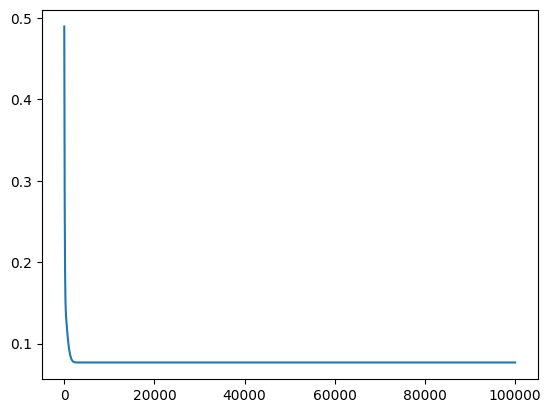

In [6]:
#iterer pour poursuivre l'entrainement
iter = 100000
losses = []

for _ in range(iter):
    optimizer.zero_grad()
    y_pred = x_gt.matmul(w) + b
    loss = criterion(y_pred,y_gt)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
plt.plot(losses)

In [7]:
print("GT",w_gt.numpy(), b_gt.item())
print("Pred",w.detach().numpy(), b.detach())

GT [[0.74506277]
 [0.82828903]
 [0.31968415]] 0.5530157685279846
Pred [[0.71820116]
 [0.85370564]
 [0.36851296]] tensor([[1.0220]])


# Implementation avec nn.Module

Les éléments qui doivent changer sont :
- le forward qui passe de l'equation à la fonction linear de pytorch
- les variable doivent etre passées au GPU
- les fonction de calcul de cout et d'optimisation ne changent pas

In [8]:
class H(torch.nn.Module):

    def __init__(self, in_features, out_features):
        super(H, self).__init__()

        self.linear1 = torch.nn.Linear(in_features, out_features)
    def forward(self, x):
        x = self.linear1(x)
        return x

In [9]:
model = H(input_features, out_features)

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
x_gt = x_gt.to(device)
y_gt = y_gt.to(device)

In [11]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

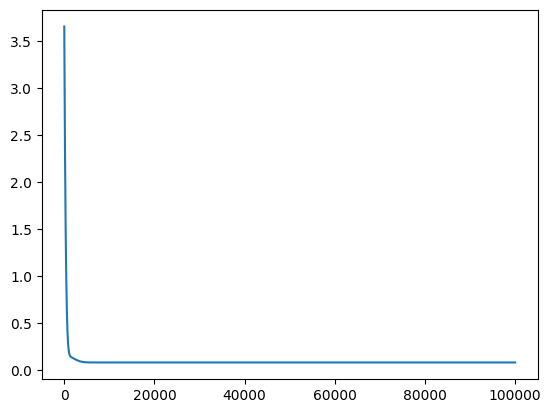

In [12]:
iter = 100000
losses = []

for _ in range(iter):
  optimizer.zero_grad()
  y_pred = model(x_gt)
  loss = criterion(y_pred,y_gt)
  loss.backward()
  optimizer.step()
  losses.append(loss.item())
plt.plot(losses)

In [13]:
print("GT",w_gt.numpy(), b_gt.item())
print("Pred",model.linear1.weight.detach().numpy(), model.linear1.bias.detach())

GT [[0.74506277]
 [0.82828903]
 [0.31968415]] 0.5530157685279846
Pred [[0.7181992  0.8537035  0.36851087]] tensor([1.0220])


# Sauvegarde du model

In [14]:
#Sauvegarde
torch.save(model.state_dict(),'my_first_model')

#Tentative de lecture
model.load_state_dict(torch.load('my_first_model'))

<All keys matched successfully>

# Tester mon model

In [15]:
x_new = torch.rand(3).unsqueeze(0).to(device)

x_new.shape,x_gt.shape

model(x_new)

tensor([[1.5023]], grad_fn=<AddmmBackward0>)